In [1]:
#cell 1
print("cell testing...")


cell testing...


In [5]:
#cell 2
# Step-1: Prepare a classification dataset (Tumor = 1, No Tumor = 0)
# Model name: ConvNeXt-tiny
import os, random, shutil

# Input directories (original images + masks)
IMG_DIR = "/kaggle/input/litsdataset2/images"
MASK_DIR = "/kaggle/input/litsdataset2/masks"

# Output directory (new classification folder structure)
OUT_DIR = "/kaggle/working/class_dataset"

# Step-2: Create folders for train/val and labels (0 = no tumor, 1 = tumor)
for split in ["train", "val"]:
    for cls in ["0", "1"]:
        os.makedirs(f"{OUT_DIR}/{split}/{cls}", exist_ok=True)

# Step-3: Load all image file names and shuffle them
images = [f for f in os.listdir(IMG_DIR) if f.endswith(".png")]
random.shuffle(images)

# Step-4: 70-30 split
split_idx = int(len(images) * 0.7)
train_files = images[:split_idx]
val_files   = images[split_idx:]

# Step-5: Simple tumor check using mask file size
def is_tumor(mask_path):
    return os.path.getsize(mask_path) > 1200

# Step-6: Process and copy images into class folders
def process(files, split):
    for i, f in enumerate(files):
        img_path = os.path.join(IMG_DIR, f)
        mask_path = os.path.join(MASK_DIR, f)
        
        label = "1" if is_tumor(mask_path) else "0"
        dst = os.path.join(OUT_DIR, split, label, f)
        shutil.copyfile(img_path, dst)
        
        if i % 5000 == 0:
            print(split, i, "/", len(files))

# Step-7: Run processing
print("Processing train...")
process(train_files, "train")

print("Processing val...")
process(val_files, "val")

print("✅ Dataset preparation DONE!")

Processing train...
train 0 / 41046
train 5000 / 41046
train 10000 / 41046
train 15000 / 41046
train 20000 / 41046
train 25000 / 41046
train 30000 / 41046
train 35000 / 41046
train 40000 / 41046
Processing val...
val 0 / 17592
val 5000 / 17592
val 10000 / 17592
val 15000 / 17592
✅ Dataset preparation DONE!


In [6]:
#cell 3
import os

base = "/kaggle/working/class_dataset"

print("="*50)
print("📂 Dataset Structure Verification")
print("="*50)

for split in ["train", "val"]:
    for cls in ["0", "1"]:
        path = f"{base}/{split}/{cls}"
        if os.path.exists(path):
            count = len(os.listdir(path))
            print(f"{path} => {count} files")
        else:
            print(f"❌ {path} => NOT FOUND!")
print("="*50)

📂 Dataset Structure Verification
/kaggle/working/class_dataset/train/0 => 46136 files
/kaggle/working/class_dataset/train/1 => 11821 files
/kaggle/working/class_dataset/val/0 => 25831 files
/kaggle/working/class_dataset/val/1 => 6570 files


In [7]:
#cell 4
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from torch.cuda.amp import GradScaler, autocast
import timm
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report, 
    roc_curve, auc, precision_recall_fscore_support,
    accuracy_score, roc_auc_score
)
from sklearn.preprocessing import label_binarize
import warnings
warnings.filterwarnings('ignore')

# ---------------------------
# Dataset path
# ---------------------------
DATA_DIR = "/kaggle/working/class_dataset"
TRAIN_DIR = os.path.join(DATA_DIR, "train")
VAL_DIR   = os.path.join(DATA_DIR, "val")

# ---------------------------
# Image transforms
# ---------------------------
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 4

train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.485,0.456,0.406),(0.229,0.224,0.225)),
])

val_transforms = transforms.Compose([
    transforms.Resize(int(IMG_SIZE*1.1)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize((0.485,0.456,0.406),(0.229,0.224,0.225)),
])

# ---------------------------
# Datasets & DataLoaders
# ---------------------------
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
val_dataset   = datasets.ImageFolder(VAL_DIR, transform=val_transforms)

NUM_CLASSES = len(train_dataset.classes)
class_names = train_dataset.classes

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print("="*60)
print("📊 Dataset Information")
print("="*60)
print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")
print(f"Classes: {class_names}")
print(f"Number of classes: {NUM_CLASSES}")
print("="*60)

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

📊 Dataset Information
Train samples: 57957
Val samples: 32401
Classes: ['0', '1']
Number of classes: 2


In [8]:
#cell 5
# ---------------------------
# Device setup
# ---------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"\n🖥️  Using device: {DEVICE}")

# ---------------------------
# ConvNeXt model setup
# ---------------------------
model = timm.create_model("convnext_tiny", pretrained=True, num_classes=NUM_CLASSES)
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)

scaler = GradScaler()

print("✅ ConvNeXt-Tiny model loaded successfully!")
print(f"📌 Total parameters: {sum(p.numel() for p in model.parameters()):,}")


🖥️  Using device: cuda


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

✅ ConvNeXt-Tiny model loaded successfully!
📌 Total parameters: 27,821,666


In [9]:
#cell 6
# ---------------------------
# Training function
# ---------------------------
def train_one_epoch(model, loader, criterion, optimizer, scaler, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    progress_bar = tqdm(loader, desc="Training", leave=False)
    
    for images, labels in progress_bar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        with autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
        progress_bar.set_postfix(loss=loss.item())
    
    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    
    # Calculate precision, recall, F1
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='weighted', zero_division=0
    )
    
    return epoch_loss, epoch_acc, precision, recall, f1


# ---------------------------
# Validation function
# ---------------------------
def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    all_probs = []
    
    progress_bar = tqdm(loader, desc="Validation", leave=False)
    
    with torch.no_grad():
        for images, labels in progress_bar:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            
            progress_bar.set_postfix(loss=loss.item())
    
    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    
    # Calculate precision, recall, F1
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='weighted', zero_division=0
    )
    
    return epoch_loss, epoch_acc, precision, recall, f1, all_preds, all_labels, all_probs

print("✅ Training and validation functions defined!")

✅ Training and validation functions defined!


In [10]:
#cell 7
# ---------------------------
# Training configuration
# ---------------------------
NUM_EPOCHS = 30  #for 30 epochs
best_val_acc = 0.0
best_epoch = 0

# History tracking
history = {
    'train_loss': [], 'train_acc': [], 'train_precision': [], 'train_recall': [], 'train_f1': [],
    'val_loss': [], 'val_acc': [], 'val_precision': [], 'val_recall': [], 'val_f1': []
}

# To store best model predictions for final evaluation
best_preds = None
best_labels = None
best_probs = None

print("\n" + "="*60)
print("🚀 Starting Training...")
print("="*60)

# ---------------------------
# Training loop
# ---------------------------
for epoch in range(NUM_EPOCHS):
    print(f"\n📍 Epoch {epoch+1}/{NUM_EPOCHS}")
    print("-" * 60)
    
    # Train
    train_loss, train_acc, train_prec, train_rec, train_f1 = train_one_epoch(
        model, train_loader, criterion, optimizer, scaler, DEVICE
    )
    
    # Validate
    val_loss, val_acc, val_prec, val_rec, val_f1, val_preds, val_labels, val_probs = validate(
        model, val_loader, criterion, DEVICE
    )
    
    # Update learning rate
    scheduler.step()
    
    # Save metrics
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_precision'].append(train_prec)
    history['train_recall'].append(train_rec)
    history['train_f1'].append(train_f1)
    
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_precision'].append(val_prec)
    history['val_recall'].append(val_rec)
    history['val_f1'].append(val_f1)
    
    # Print epoch results
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train Prec: {train_prec:.4f} | Train Rec: {train_rec:.4f} | Train F1: {train_f1:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f} | Val Prec:   {val_prec:.4f} | Val Rec:   {val_rec:.4f} | Val F1:   {val_f1:.4f}")
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        best_preds = val_preds
        best_labels = val_labels
        best_probs = val_probs
        torch.save(model.state_dict(), 'best_convnext_model.pth')
        print(f"✅ Best model saved! (Epoch {best_epoch}, Val Acc: {best_val_acc:.4f})")

print("\n" + "="*60)
print("🎉 Training Complete!")
print("="*60)
print(f"🏆 Best Epoch: {best_epoch}")
print(f"🏆 Best Validation Accuracy: {best_val_acc:.4f}")


🚀 Starting Training...

📍 Epoch 1/30
------------------------------------------------------------


Train Loss: 0.1071 | Train Acc: 0.9587 | Train Prec: 0.9583 | Train Rec: 0.9587 | Train F1: 0.9584
Val Loss:   0.0382 | Val Acc:   0.9850 | Val Prec:   0.9851 | Val Rec:   0.9850 | Val F1:   0.9850
✅ Best model saved! (Epoch 1, Val Acc: 0.9850)

📍 Epoch 2/30
------------------------------------------------------------


Train Loss: 0.0727 | Train Acc: 0.9707 | Train Prec: 0.9705 | Train Rec: 0.9707 | Train F1: 0.9705
Val Loss:   0.0587 | Val Acc:   0.9764 | Val Prec:   0.9770 | Val Rec:   0.9764 | Val F1:   0.9759

📍 Epoch 3/30
------------------------------------------------------------


Train Loss: 0.0640 | Train Acc: 0.9749 | Train Prec: 0.9748 | Train Rec: 0.9749 | Train F1: 0.9749
Val Loss:   0.0349 | Val Acc:   0.9867 | Val Prec:   0.9868 | Val Rec:   0.9867 | Val F1:   0.9866
✅ Best model saved! (Epoch 3, Val Acc: 0.9867)

📍 Epoch 4/30
------------------------------------------------------------


Train Loss: 0.0592 | Train Acc: 0.9767 | Train Prec: 0.9766 | Train Rec: 0.9767 | Train F1: 0.9767
Val Loss:   0.0255 | Val Acc:   0.9892 | Val Prec:   0.9892 | Val Rec:   0.9892 | Val F1:   0.9891
✅ Best model saved! (Epoch 4, Val Acc: 0.9892)

📍 Epoch 5/30
------------------------------------------------------------


...

Train Loss: 0.0154 | Train Acc: 0.9942 | Train Prec: 0.9941 | Train Rec: 0.9942 | Train F1: 0.9941
Val Loss:   0.0041 | Val Acc:   0.9984 | Val Prec:   0.9984 | Val Rec:   0.9984 | Val F1:   0.9984

📍 Epoch 27/30
------------------------------------------------------------


Train Loss: 0.0166 | Train Acc: 0.9935 | Train Prec: 0.9935 | Train Rec: 0.9935 | Train F1: 0.9935
Val Loss:   0.0037 | Val Acc:   0.9986 | Val Prec:   0.9986 | Val Rec:   0.9986 | Val F1:   0.9986
✅ Best model saved! (Epoch 27, Val Acc: 0.9986)

📍 Epoch 28/30
------------------------------------------------------------


Train Loss: 0.0139 | Train Acc: 0.9946 | Train Prec: 0.9946 | Train Rec: 0.9946 | Train F1: 0.9946
Val Loss:   0.0036 | Val Acc:   0.9986 | Val Prec:   0.9986 | Val Rec:   0.9986 | Val F1:   0.9986

📍 Epoch 29/30
------------------------------------------------------------


Train Loss: 0.0139 | Train Acc: 0.9943 | Train Prec: 0.9943 | Train Rec: 0.9943 | Train F1: 0.9943
Val Loss:   0.0036 | Val Acc:   0.9988 | Val Prec:   0.9988 | Val Rec:   0.9988 | Val F1:   0.9988
✅ Best model saved! (Epoch 29, Val Acc: 0.9988)

📍 Epoch 30/30
------------------------------------------------------------


Train Loss: 0.0139 | Train Acc: 0.9945 | Train Prec: 0.9945 | Train Rec: 0.9945 | Train F1: 0.9945
Val Loss:   0.0036 | Val Acc:   0.9988 | Val Prec:   0.9988 | Val Rec:   0.9988 | Val F1:   0.9988

🎉 Training Complete!
🏆 Best Epoch: 29
🏆 Best Validation Accuracy: 0.9988




          📋  VALIDATION SUMMARY TABLE
  Metric                                        Value
----------------------------------------------------------
  Accuracy                                     99.88%
  Precision (weighted)                         99.88%
  Recall / Sensitivity (weighted)              99.88%
  F1-Score (weighted)                          99.88%
  ROC-AUC                                      1.0000
  Specificity                                  99.92%
----------------------------------------------------------
  Best Epoch                                       29
  Train Loss (Best Epoch)                      0.0139
  Val Loss   (Best Epoch)                      0.0036
----------------------------------------------------------
  TP                                             6550
  TN                                            25811
  FP                                               20
  FN                                               20


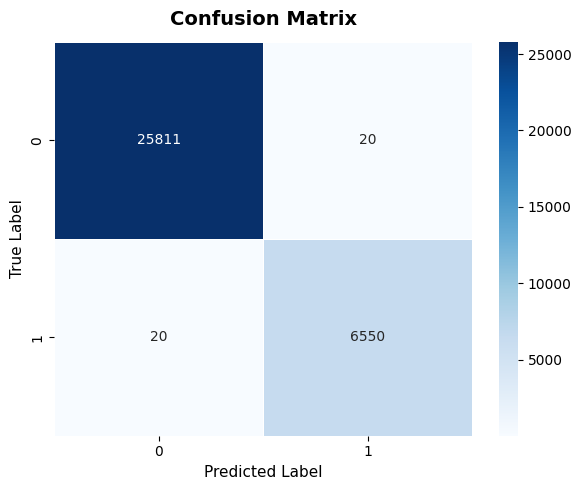

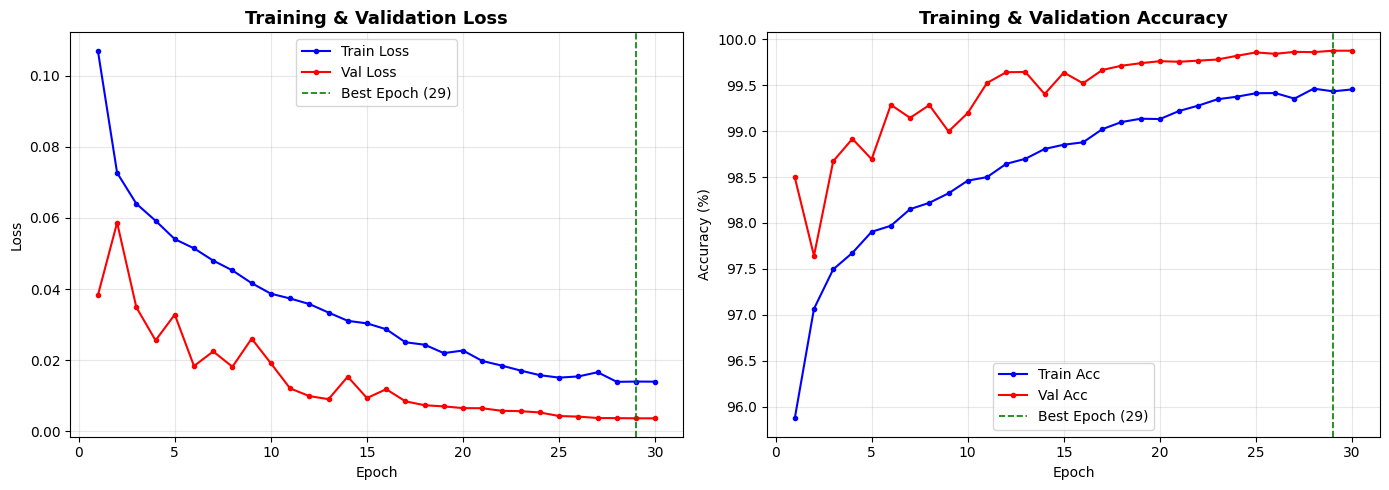

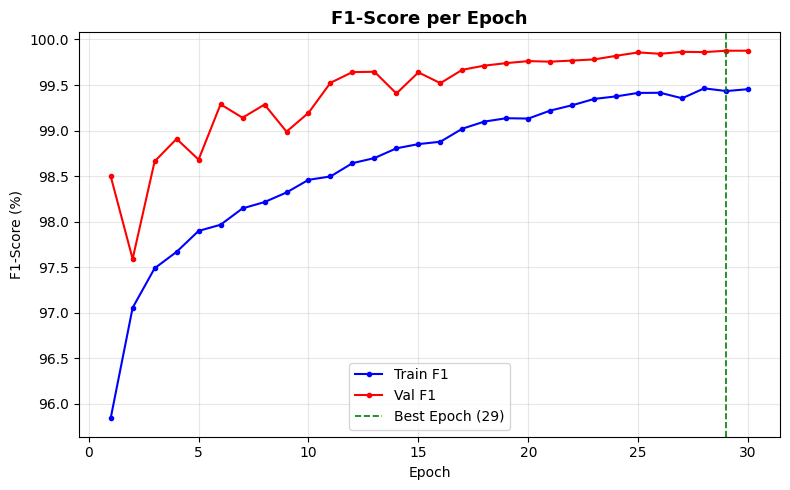

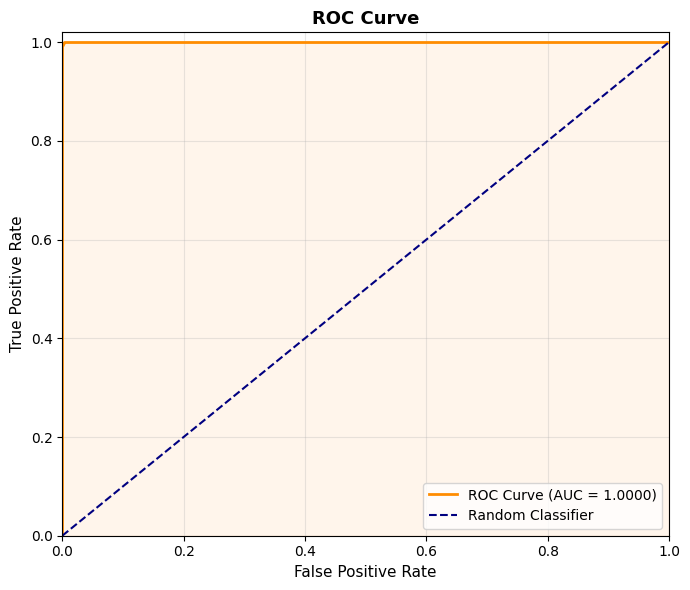

✅ ROC Curve saved. (AUC: 1.0000)


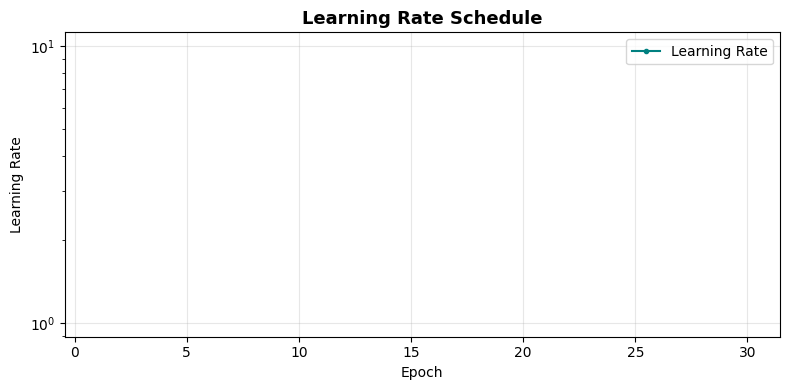

✅ All plots saved to /kaggle/working/


In [13]:
# ============================================================
# CELL 8: Full Evaluation — Table + All Curves
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, roc_curve, auc,
    precision_recall_fscore_support,
    accuracy_score, roc_auc_score
)
import torch

# ── Use best epoch's predictions (saved during training loop) ──
all_preds  = np.array(best_preds)
all_labels = np.array(best_labels)
all_probs = np.array(best_probs)
if all_probs.ndim == 2:
    all_probs = all_probs[:, 1]

# ── Confusion Matrix values ───────────────────────────────────
cm             = confusion_matrix(all_labels, all_preds)
TN, FP, FN, TP = cm.ravel()

# ── Core Metrics ──────────────────────────────────────────────
accuracy    = accuracy_score(all_labels, all_preds)
roc_auc     = roc_auc_score(all_labels, all_probs)
specificity = TN / (TN + FP)

precision, recall, f1, _ = precision_recall_fscore_support(
    all_labels, all_preds, average='weighted'
)

# ── Pull history variables from history dict ──────────────────
train_loss_history = history['train_loss']
val_loss_history   = history['val_loss']
train_acc_history  = history['train_acc']
val_acc_history    = history['val_acc']
val_f1_history     = history['val_f1']
epochs_range       = range(1, len(train_loss_history) + 1)

# ── Best Epoch info ───────────────────────────────────────────
best_train_loss = train_loss_history[best_epoch - 1]
best_val_loss   = val_loss_history[best_epoch - 1]

# ============================================================
# VALIDATION SUMMARY TABLE (printed, not image)
# ============================================================
print("\n")
print("=" * 58)
print("          📋  VALIDATION SUMMARY TABLE")
print("=" * 58)
print(f"  {'Metric':<32} {'Value':>18}")
print("-" * 58)
print(f"  {'Accuracy':<32} {accuracy*100:>17.2f}%")
print(f"  {'Precision (weighted)':<32} {precision*100:>17.2f}%")
print(f"  {'Recall / Sensitivity (weighted)':<32} {recall*100:>17.2f}%")
print(f"  {'F1-Score (weighted)':<32} {f1*100:>17.2f}%")
print(f"  {'ROC-AUC':<32} {roc_auc:>18.4f}")
print(f"  {'Specificity':<32} {specificity*100:>17.2f}%")
print("-" * 58)
print(f"  {'Best Epoch':<32} {best_epoch:>18}")
print(f"  {'Train Loss (Best Epoch)':<32} {best_train_loss:>18.4f}")
print(f"  {'Val Loss   (Best Epoch)':<32} {best_val_loss:>18.4f}")
print("-" * 58)
print(f"  {'TP':<32} {TP:>18}")
print(f"  {'TN':<32} {TN:>18}")
print(f"  {'FP':<32} {FP:>18}")
print(f"  {'FN':<32} {FN:>18}")
print("=" * 58)

# ============================================================
# PLOT 1: Confusion Matrix Heatmap
# ============================================================
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            linewidths=0.5, ax=ax)
ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150)
plt.show()

# ============================================================
# PLOT 2: Accuracy + Loss Curve (Combined)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, train_loss_history, 'b-o', markersize=3, label='Train Loss')
axes[0].plot(epochs_range, val_loss_history,   'r-o', markersize=3, label='Val Loss')
axes[0].axvline(x=best_epoch, color='green', linestyle='--', linewidth=1.2, label=f'Best Epoch ({best_epoch})')
axes[0].set_title('Training & Validation Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, [a*100 for a in train_acc_history], 'b-o', markersize=3, label='Train Acc')
axes[1].plot(epochs_range, [a*100 for a in val_acc_history],   'r-o', markersize=3, label='Val Acc')
axes[1].axvline(x=best_epoch, color='green', linestyle='--', linewidth=1.2, label=f'Best Epoch ({best_epoch})')
axes[1].set_title('Training & Validation Accuracy', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/acc_loss_curve.png', dpi=150)
plt.show()

# ============================================================
# PLOT 3: F1-Score Curve
# ============================================================
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(epochs_range, [f*100 for f in history['train_f1']], 'b-o', markersize=3, label='Train F1')
ax.plot(epochs_range, [f*100 for f in val_f1_history],      'r-o', markersize=3, label='Val F1')
ax.axvline(x=best_epoch, color='green', linestyle='--', linewidth=1.2, label=f'Best Epoch ({best_epoch})')
ax.set_title('F1-Score per Epoch', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('F1-Score (%)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/f1_curve.png', dpi=150)
plt.show()

# ============================================================
# PLOT 4: ROC Curve
# ============================================================
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc_val = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc_val:.4f})')
ax.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.08, color='darkorange')
ax.set_xlim([0.0, 1.0]); ax.set_ylim([0.0, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curve', fontsize=13, fontweight='bold')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/roc_curve.png', dpi=150)
plt.show()
print(f"✅ ROC Curve saved. (AUC: {roc_auc_val:.4f})")

# ============================================================
# PLOT 5: Learning Rate Curve
# ============================================================
if 'lr' in history:
    lr_history = history['lr']
else:
    lr_history = [optimizer.param_groups[0]['lr']] * len(train_loss_history)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(epochs_range, lr_history, 'teal', marker='o', markersize=3, label='Learning Rate')
ax.set_title('Learning Rate Schedule', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Learning Rate')
ax.set_yscale('log')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/lr_curve.png', dpi=150)
plt.show()
print("✅ All plots saved to /kaggle/working/")